In [35]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy.stats import pearsonr, ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
df = pd.read_csv("Fifa 23 Players Data.csv")


In [7]:
# Standardize expected column names for this dataset
if 'Full Name' in df.columns:
    df['Name'] = df['Full Name']
elif 'Known As' in df.columns:
    df['Name'] = df['Known As']

if 'Club Name' in df.columns:
    df['Club'] = df['Club Name']

if 'Value(in Euro)' in df.columns:
    df.rename(columns={'Value(in Euro)': 'Value'}, inplace=True)

if 'Wage(in Euro)' in df.columns:
    df.rename(columns={'Wage(in Euro)': 'Wage'}, inplace=True)


In [8]:
# Preview data
print(df.head())

         Known As           Full Name  Overall  Potential      Value  \
0        L. Messi        Lionel Messi       91         91   54000000   
1      K. Benzema       Karim Benzema       91         91   64000000   
2  R. Lewandowski  Robert Lewandowski       91         91   84000000   
3    K. De Bruyne     Kevin De Bruyne       91         91  107500000   
4       K. Mbappé       Kylian Mbappé       91         95  190500000   

  Positions Played Best Position Nationality  \
0               RW           CAM   Argentina   
1            CF,ST            CF      France   
2               ST            ST      Poland   
3           CM,CAM            CM     Belgium   
4            ST,LW            ST      France   

                                         Image Link  Age  ...  RM Rating  \
0  https://cdn.sofifa.net/players/158/023/23_60.png   35  ...         91   
1  https://cdn.sofifa.net/players/165/153/23_60.png   34  ...         89   
2  https://cdn.sofifa.net/players/188/545/23_60.pn

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18539 entries, 0 to 18538
Data columns (total 91 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Known As                     18539 non-null  object
 1   Full Name                    18539 non-null  object
 2   Overall                      18539 non-null  int64 
 3   Potential                    18539 non-null  int64 
 4   Value                        18539 non-null  int64 
 5   Positions Played             18539 non-null  object
 6   Best Position                18539 non-null  object
 7   Nationality                  18539 non-null  object
 8   Image Link                   18539 non-null  object
 9   Age                          18539 non-null  int64 
 10  Height(in cm)                18539 non-null  int64 
 11  Weight(in kg)                18539 non-null  int64 
 12  TotalStats                   18539 non-null  int64 
 13  BaseStats                    18

In [10]:
print(df.describe())

            Overall     Potential         Value           Age  Height(in cm)  \
count  18539.000000  18539.000000  1.853900e+04  18539.000000   18539.000000   
mean      65.852042     71.016668  2.875461e+06     25.240412     181.550839   
std        6.788353      6.192866  7.635129e+06      4.718163       6.858097   
min       47.000000     48.000000  0.000000e+00     16.000000     155.000000   
25%       62.000000     67.000000  4.750000e+05     21.000000     177.000000   
50%       66.000000     71.000000  1.000000e+06     25.000000     182.000000   
75%       70.000000     75.000000  2.000000e+06     29.000000     186.000000   
max       91.000000     95.000000  1.905000e+08     44.000000     206.000000   

       Weight(in kg)    TotalStats     BaseStats           Wage  \
count   18539.000000  18539.000000  18539.000000   18539.000000   
mean       75.173904   1602.114569    357.946221    8824.537462   
std         7.013593    273.160237     39.628259   19460.531154   
min        

In [11]:
df = df.drop(columns=['Photo', 'Flag', 'Club Logo', 'Real Face'], errors='ignore')

In [12]:
def to_numeric_value(value):
    if isinstance(value, str):
        cleaned = value.replace('€', '').replace('M', 'e6').replace('K', 'e3')
        try:
            return float(cleaned)
        except ValueError:
            return pd.NA
    return pd.to_numeric(value, errors='coerce')


In [13]:
if 'Value' in df.columns:
    df['Value'] = df['Value'].apply(to_numeric_value)

if 'Wage' in df.columns:
    df['Wage'] = df['Wage'].apply(to_numeric_value)

# Drop rows missing required columns or values
required_columns = ['Name', 'Club', 'Age', 'Overall', 'Potential', 'Value', 'Wage', 'Finishing', 'Positioning', 'Shot Power']
missing_required = [col for col in required_columns if col not in df.columns]
if missing_required:
    raise KeyError(f"Missing required columns: {missing_required}")

df = df.dropna(subset=required_columns)

df['Attack Score'] = (df['Finishing'] + df['Positioning'] + df['Shot Power']) / 3

df['Efficiency'] = df['Overall'] / df['Potential']

df['Value Efficiency'] = df['Overall'] / df['Value'].replace(0, pd.NA)

In [14]:
def categorize_player(overall):
    if overall >= 85:
        return "Elite"
    elif overall >= 75:
        return "Good"
    return "Average"


In [15]:
df['Player Level'] = df['Overall'].apply(categorize_player)

In [16]:
df_clean = df[[
    'Name',
    'Club',
    'Age',
    'Overall',
    'Potential',
    'Value',
    'Wage',
    'Attack Score',
    'Efficiency',
    'Value Efficiency',
    'Player Level'
]]

In [17]:
print(df_clean.describe())
df_clean.to_csv("cleaned_fifa23_data.csv", index=False)


                Age       Overall     Potential         Value           Wage  \
count  18539.000000  18539.000000  18539.000000  1.853900e+04   18539.000000   
mean      25.240412     65.852042     71.016668  2.875461e+06    8824.537462   
std        4.718163      6.788353      6.192866  7.635129e+06   19460.531154   
min       16.000000     47.000000     48.000000  0.000000e+00       0.000000   
25%       21.000000     62.000000     67.000000  4.750000e+05    1000.000000   
50%       25.000000     66.000000     71.000000  1.000000e+06    3000.000000   
75%       29.000000     70.000000     75.000000  2.000000e+06    8000.000000   
max       44.000000     91.000000     95.000000  1.905000e+08  450000.000000   

       Attack Score    Efficiency  
count  18539.000000  18539.000000  
mean      51.534441      0.928842  
std       16.172749      0.072979  
min       14.666667      0.666667  
25%       39.666667      0.877058  
50%       55.000000      0.946429  
75%       64.000000      1.

In [18]:
cleaned_df = pd.read_csv("cleaned_fifa23_data.csv")
print("First 5 rows of the cleaned dataset:")
display(cleaned_df.head())

First 5 rows of the cleaned dataset:


,Name,Club,Age,Overall,Potential,Value,Wage,Attack Score,Efficiency,Value Efficiency,Player Level
0,Lionel Messi,Paris Saint-Germain,35,91,91,54000000,195000,89.666667,1.000000,1.685185e-06,Elite
1,Karim Benzema,Real Madrid CF,34,91,91,64000000,450000,90.333333,1.000000,1.421875e-06,Elite
2,Robert Lewandowski,FC Barcelona,33,91,91,84000000,420000,93.000000,1.000000,1.083333e-06,Elite
3,Kevin De Bruyne,Manchester City,31,91,91,107500000,350000,88.333333,1.000000,8.465116e-07,Elite
4,Kylian Mbappé,Paris Saint-Germain,23,91,95,190500000,230000,91.000000,0.957895,4.776903e-07,Elite


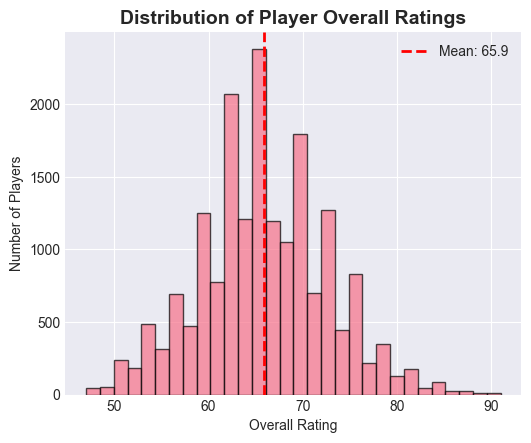

In [20]:
# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create a figure with multiple subplots
fig = plt.figure(figsize=(20, 16))

# 1. Distribution of Player Overall Ratings
ax1 = fig.add_subplot(3, 3, 1)
df['Overall'].hist(bins=30, edgecolor='black', alpha=0.7)
ax1.set_title('Distribution of Player Overall Ratings', fontsize=14, fontweight='bold')
ax1.set_xlabel('Overall Rating')
ax1.set_ylabel('Number of Players')
ax1.axvline(df['Overall'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df["Overall"].mean():.1f}')
ax1.legend()

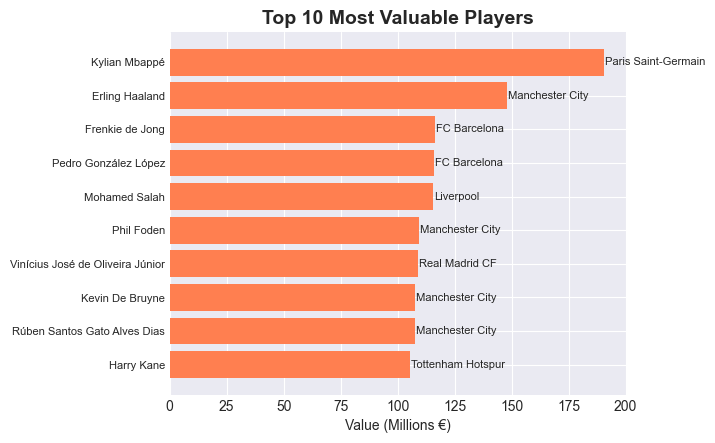

In [21]:
# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create a figure with multiple subplots
fig = plt.figure(figsize=(20, 16))

# 2. Top 10 Most Valuable Players
ax4 = fig.add_subplot(3, 3, 4)
top_valuable = df.nlargest(10, 'Value')[['Name', 'Value', 'Club']]
bars = ax4.barh(range(len(top_valuable)), top_valuable['Value'].values / 1e6, color='coral')
ax4.set_yticks(range(len(top_valuable)))
ax4.set_yticklabels(top_valuable['Name'].values, fontsize=8)
ax4.set_xlabel('Value (Millions €)')
ax4.set_title('Top 10 Most Valuable Players', fontsize=14, fontweight='bold')
ax4.invert_yaxis()
# Add club names as text
for i, (idx, row) in enumerate(top_valuable.iterrows()):
    ax4.text(row['Value']/1e6 + 0.5, i, row['Club'], va='center', fontsize=8)

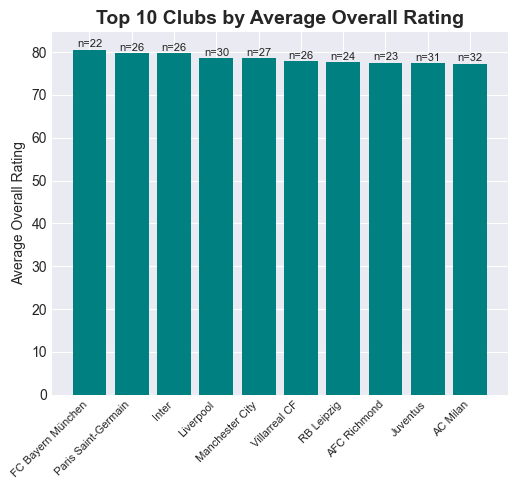

In [22]:
# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create a figure with multiple subplots
fig = plt.figure(figsize=(20, 16))
#3. Top 10 Clubs by Average Overall Rating
ax8 = fig.add_subplot(3, 3, 8)
top_clubs = df.groupby('Club').agg({'Overall': 'mean', 'Name': 'count'}).nlargest(10, 'Overall')
bars = ax8.bar(range(len(top_clubs)), top_clubs['Overall'].values, color='teal')
ax8.set_xticks(range(len(top_clubs)))
ax8.set_xticklabels(top_clubs.index, rotation=45, ha='right', fontsize=8)
ax8.set_ylabel('Average Overall Rating')
ax8.set_title('Top 10 Clubs by Average Overall Rating', fontsize=14, fontweight='bold')
# Add player count as text
for i, (idx, row) in enumerate(top_clubs.iterrows()):
    ax8.text(i, row['Overall'] + 0.5, f'n={int(row["Name"])}', ha='center', fontsize=8)


--- CORRELATION MATRIX ---
                       Age   Overall  Potential     Value      Wage  \
Age               1.000000  0.442369  -0.263686  0.030662  0.144251   
Overall           0.442369  1.000000   0.660630  0.561642  0.599129   
Potential        -0.263686  0.660630   1.000000  0.532835  0.497392   
Value             0.030662  0.561642   0.532835  1.000000  0.822262   
Wage              0.144251  0.599129   0.497392  0.822262  1.000000   
Attack Score      0.142920  0.422768   0.273780  0.257721  0.275865   
Efficiency        0.867757  0.562593  -0.246103  0.121912  0.206021   
Value Efficiency  0.134455 -0.521460  -0.568861 -0.206431 -0.219429   

                  Attack Score  Efficiency  Value Efficiency  
Age                   0.142920    0.867757          0.134455  
Overall               0.422768    0.562593         -0.521460  
Potential             0.273780   -0.246103         -0.568861  
Value                 0.257721    0.121912         -0.206431  
Wage             

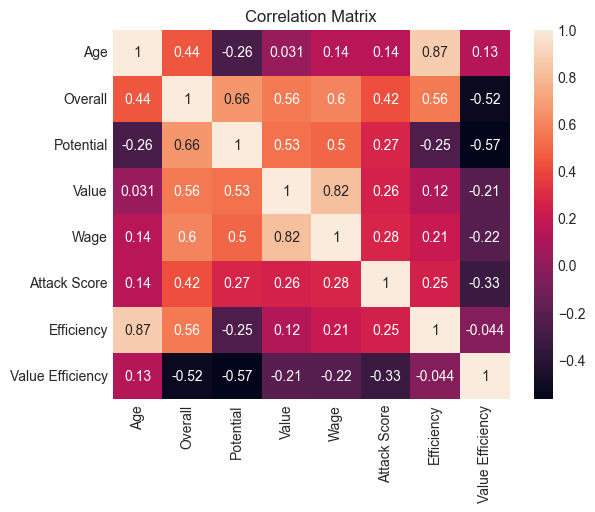

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
corr_matrix = cleaned_df.corr(numeric_only=True)

print("\n--- CORRELATION MATRIX ---")
print(corr_matrix)

# Heatmap
plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Get unique clubs from different categories
elite_clubs = set(df[df['Player Level'] == 'Elite']['Club'].unique())
good_clubs = set(df[df['Player Level'] == 'Good']['Club'].unique())
average_clubs = set(df[df['Player Level'] == 'Average']['Club'].unique())

# Find clubs that have both Elite and Good players
elite_and_good = np.intersect1d(list(elite_clubs), list(good_clubs))
print(f"\nClubs with both Elite and Good players: {len(elite_and_good)}")
print(f"Example: {list(elite_and_good)[:5]}")

# Find all unique clubs (union)
all_clubs = np.union1d(np.union1d(list(elite_clubs), list(good_clubs)), list(average_clubs))
print(f"Total unique clubs: {len(all_clubs)}")

# Clubs with only Elite players (set difference)
elite_only = np.setdiff1d(list(elite_clubs), list(good_clubs))
print(f"Clubs with ONLY Elite players: {len(elite_only)}")

NameError: name 'cleaned_df' is not defined

In [24]:
from scipy.stats import ttest_ind

# Separate groups
elite = cleaned_df[cleaned_df['Player Level'] == 'Elite']['Overall']
average = cleaned_df[cleaned_df['Player Level'] == 'Average']['Overall']

# Perform t-test
t_stat, p_value = ttest_ind(elite, average)

print("\n--- T-TEST RESULT ---")
print("T-Statistic:", t_stat)
print("P-Value:", p_value)


--- T-TEST RESULT ---
T-Statistic: 38.30642353422582
P-Value: 8.158053163665257e-308


In [25]:
if p_value < 0.05:
    print("Reject Null Hypothesis: Significant difference exists")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis: Significant difference exists


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = cleaned_df[['Value']]
y = cleaned_df['Overall']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- MODEL PERFORMANCE ---")
print("Mean Squared Error:", mse)
print("R2 Score:", r2)


--- MODEL PERFORMANCE ---
Mean Squared Error: 31.510107739487346
R2 Score: 0.3188763311543682


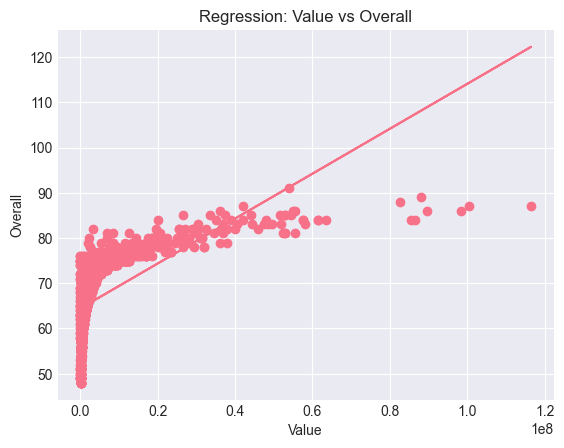

In [27]:
plt.figure()
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Value")
plt.ylabel("Overall")
plt.title("Regression: Value vs Overall")
plt.show()

In [28]:
from scipy.stats import pearsonr

corr, p_val = pearsonr(cleaned_df['Value'], cleaned_df['Overall'])

print("\n--- PEARSON TEST ---")
print("Correlation:", corr)
print("P-value:", p_val)


--- PEARSON TEST ---
Correlation: 0.5616422900267181
P-value: 0.0


In [30]:
import pandas as pd
cleaned_df = pd.read_csv("Cleaned_fifa23_data.csv")
print("First 5 rows of the cleaned dataset:")
display(cleaned_df.head())
     

First 5 rows of the cleaned dataset:


,Name,Club,Age,Overall,Potential,Value,Wage,Attack Score,Efficiency,Value Efficiency,Player Level
0,Lionel Messi,Paris Saint-Germain,35,91,91,54000000,195000,89.666667,1.000000,1.685185e-06,Elite
1,Karim Benzema,Real Madrid CF,34,91,91,64000000,450000,90.333333,1.000000,1.421875e-06,Elite
2,Robert Lewandowski,FC Barcelona,33,91,91,84000000,420000,93.000000,1.000000,1.083333e-06,Elite
3,Kevin De Bruyne,Manchester City,31,91,91,107500000,350000,88.333333,1.000000,8.465116e-07,Elite
4,Kylian Mbappé,Paris Saint-Germain,23,91,95,190500000,230000,91.000000,0.957895,4.776903e-07,Elite


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define features (X) and target (y)
X = cleaned_df[['Age', 'Potential', 'Value', 'Wage', 'Attack Score', 'Efficiency']]
y = cleaned_df['Overall']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- MODEL PERFORMANCE ---")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")
     


--- MODEL PERFORMANCE ---
Mean Squared Error: 0.15
R2 Score: 1.00


In [32]:
# Create prediction column
cleaned_df['Predicted Overall'] = model.predict(
    cleaned_df[['Age', 'Potential', 'Value', 'Wage', 'Attack Score', 'Efficiency']]
)

In [33]:
print(cleaned_df[['Name', 'Overall', 'Predicted Overall']].head())

                 Name  Overall  Predicted Overall
0        Lionel Messi       91          90.730565
1       Karim Benzema       91          92.859676
2  Robert Lewandowski       91          92.696672
3     Kevin De Bruyne       91          92.250042
4       Kylian Mbappé       91          92.320797


In [34]:
cleaned_df.to_csv("advanced_fifa_data.csv", index=False)
     